# 5c -- Transferencia densa Francia -> Cataluna (Sen4AgriNet, US-075)

Cuantifica el **gap de dominio Franco-Iberico** en segmentacion densa de cultivos como
`Delta mIoU = mIoU_few_shot - mIoU_zero_shot`, sobre los MISMOS parches reales de validacion de
Cataluna (Sen4AgriNet, tile `31TCG`, anos 2019/2020), en el espacio de etiquetas macro-HCAT comun
(US-074, 10 grupos de cultivo; el fondo y lo fuera-de-nomenclatura van a `ignore_index=255`).

- **Zero-shot**: el campeon denso PASTIS-R (Francia) `tsvit-pheno-v1/best.pt` (18 clases nativo) se
  proyecta 18 -> macro via el crosswalk US-074 y se evalua tal cual sobre Cataluna, sin reentrenar.
- **Few-shot**: se finetunea una cabeza macro (encoder Francia con LR bajo 1e-5 / head nuevo 1e-4)
  con `k=10` parches de Cataluna y se evalua sobre el held-out (split a nivel de parche, anti-leakage).

> **CAVEAT cientifico (AC-5, arXiv:2601.00857).** La transferibilidad espacial de los embeddings y
> modelos de fundacion EO es **limitada**: NO se debe prometer zero-shot cross-region. Por eso el
> presupuesto de US-075 es **few-shot**, y el entregable es el **Delta mIoU** (cuanto recupera el
> adaptado con pocos parches), NO un accuracy alto. El zero-shot puede ser muy bajo -- ESO es el
> hallazgo, no un fallo.

> **Regla cero-sinteticos.** Todos los numeros provienen de parches REALES descargados de
> `paren8esis/S4A` (HF, CC-BY-SA-4.0) y de checkpoints densos REALES entrenados en H100. El notebook
> re-corre el adapter + la inferencia zero-shot sobre los `.nc` reales y lee el JSON autoritativo del
> finetune (`ml.train.finetune_sen4agrinet`). Si el finetune no hubiera convergido, se reportaria el
> zero-shot REAL + el progreso real (ver `docs/blockers/epic12-vm-setup.md` B4).


In [1]:
# Parameters cell (papermill). Defaults point at the VM layout; the orchestrator
# overrides them at execution time. ``max_eval_tiles`` caps the in-notebook
# re-evaluation so the visual demo stays fast; the headline Delta comes from the
# authoritative finetune JSON (full val fold), not from this capped pass.
subset_root = "data/sen4agrinet"
fr_ckpt = "checkpoints/segmentation/tsvit-pheno-v1/best.pt"
result_json = "reports/segmentation/sen4agrinet_transfer_result.json"
device = "cuda"
max_eval_tiles = 60
seed = 17


In [2]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import polars as pl
import torch
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

# Run from the repo root so ``import ml...`` resolves under papermill.
_here = Path.cwd()
_root = _here
for _ in range(6):
    if (_root / "pyproject.toml").exists() and (_root / "ml").is_dir():
        break
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

subset_root_p = (_root / subset_root) if not Path(subset_root).is_absolute() else Path(subset_root)
fr_ckpt_p = (_root / fr_ckpt) if not Path(fr_ckpt).is_absolute() else Path(fr_ckpt)
result_json_p = (_root / result_json) if not Path(result_json).is_absolute() else Path(result_json)
dev = torch.device(device if torch.cuda.is_available() else "cpu")
print("repo root :", _root)
print("subset    :", subset_root_p, "exists=", subset_root_p.exists())
print("fr_ckpt   :", fr_ckpt_p, "exists=", fr_ckpt_p.exists())
print("device    :", dev, "| cuda:", torch.cuda.is_available())


repo root : F:\projects\agrosat-copilot
subset    : F:\projects\agrosat-copilot\data\sen4agrinet exists= True
fr_ckpt   : F:\projects\agrosat-copilot\checkpoints\segmentation\tsvit-pheno-v1\best.pt exists= True
device    : cuda | cuda: True


## Seccion 1 -- Subset Sen4AgriNet (Cataluna), datos reales

El subset descargado (`ml/ingest/sen4agrinet_download.py`) son parches netCDF reales del repo HF
`paren8esis/S4A`: Cataluna (`patch_country_code='ES'`, tile `31TCG`, 2019+2020) como dominio objetivo
y Francia (`31TCJ`, 2019) como referencia. Cada `.nc` agrupa las 13 bandas Sentinel-2 (con su propio
eje temporal y resolucion nativa 10/20/60 m) mas `labels`/`parcels` 366x366. El `.dvc` versiona el
subset; los `.nc` nunca van a git.


In [3]:
# Enumerate the real .nc patches and read the download manifest (if present).
nc_files = sorted(subset_root_p.rglob("*.nc"))
manifest_p = subset_root_p / "subset_manifest.json"
print(f"parches .nc reales encontrados: {len(nc_files)}")
if manifest_p.exists():
    man = json.loads(manifest_p.read_text(encoding="utf-8"))
    keys = [k for k in ("n_patches", "total_mb", "tiles", "years", "countries") if k in man]
    display(Markdown("**Manifiesto del subset:** " + ", ".join(f"`{k}`={man[k]}" for k in keys)))
else:
    print("(sin subset_manifest.json -- se lista directamente del arbol .nc)")
for p in nc_files[:5]:
    print("  ", p.relative_to(subset_root_p))
if len(nc_files) > 5:
    print(f"   ... (+{len(nc_files) - 5})")


parches .nc reales encontrados: 40


**Manifiesto del subset:** 

   data\2019\31TCG\2019_31TCG_patch_00_16.nc
   data\2019\31TCG\2019_31TCG_patch_00_17.nc
   data\2019\31TCG\2019_31TCG_patch_00_18.nc
   data\2019\31TCG\2019_31TCG_patch_00_19.nc
   data\2019\31TCG\2019_31TCG_patch_00_20.nc
   ... (+35)


## Seccion 2 -- El adapter netCDF -> contrato PASTIS

`Sen4AgriNetDataset` (`ml/data/sen4agrinet_adapter.py`) replica el `PAD_dataset.py` oficial: binning
mensual + interpolacion, upsample 20/60 m -> 10 m con `np.repeat`, subsample temporal equispaciado a
`T=10`, normalizacion `/10000` y tiling 366 -> 128. Las etiquetas FAO-ICC se mapean a macro-HCAT
(US-074); el fondo y lo fuera-de-nomenclatura -> `ignore_index=255`. El contrato emitido es identico al
de PASTIS-R (`x=(T,10,128,128) float32`, `y=(128,128) int64`), por eso el modelo Francia carga sin
reescribir el dataloader.


In [4]:
# Build the Catalonia-only dataset and inspect ONE real sample: shapes, value
# range and macro-label distribution. This proves the adapter contract on real .nc.
from ml.data.sen4agrinet_adapter import (
    IGNORE_INDEX,
    MACRO_GROUP_TO_ID,
    N_MACRO_CLASSES,
    Sen4AgriNetDataset,
)

ds = Sen4AgriNetDataset(root=subset_root_p, countries=("ES",), n_timesteps=10, tile_size=128)
print(f"dataset Cataluna: {len(ds)} sub-parches (tiles) de "
      f"{len(set(p for p, _, _ in ds.items))} parches; {N_MACRO_CLASSES} clases macro")

x, y = ds[0]
print(f"x shape={tuple(x.shape)} dtype={x.dtype}  rango=[{x.min():.4f}, {x.max():.4f}] media={x.mean():.4f}")
print(f"y shape={tuple(y.shape)} dtype={y.dtype}  valores={sorted(set(int(v) for v in torch.unique(y)))}")
assert tuple(x.shape) == (10, 10, 128, 128), "x no cumple el contrato PASTIS"
assert tuple(y.shape) == (128, 128), "y no cumple el contrato PASTIS"
assert 0.0 <= float(x.min()) and float(x.max()) <= 2.0, "reflectancia fuera de rango"


2026-06-20 15:06:15 [info     ] sen4agrinet_dataset_init       countries=('ES',) n_items=270 n_patches=30 n_timesteps=10 num_classes=10 precache_all=False tile_size=128


dataset Cataluna: 270 sub-parches (tiles) de 30 parches; 10 clases macro


x shape=(10, 10, 128, 128) dtype=torch.float32  rango=[0.0001, 0.4588] media=0.0667
y shape=(128, 128) dtype=torch.int64  valores=[255]


In [5]:
# Macro-label distribution over the whole Catalonia val space (real GT pixels).
id_to_name = {v: k for k, v in MACRO_GROUP_TO_ID.items()}
counts = np.zeros(N_MACRO_CLASSES, dtype=np.int64)
n_ignore = 0
n_tiles_scan = min(len(ds), 80)
for i in range(n_tiles_scan):
    _, yi = ds[i]
    yn = yi.numpy().ravel()
    n_ignore += int((yn == IGNORE_INDEX).sum())
    valid = yn[yn != IGNORE_INDEX]
    if valid.size:
        b = np.bincount(valid, minlength=N_MACRO_CLASSES)
        counts += b[:N_MACRO_CLASSES]
rows = [
    {"macro_id": c, "clase": id_to_name[c], "pixeles_GT": int(counts[c])}
    for c in range(N_MACRO_CLASSES)
]
dist = pl.DataFrame(rows).sort("pixeles_GT", descending=True)
display(Markdown(f"**Distribucion de etiquetas macro** ({n_tiles_scan} tiles, "
                 f"`ignore_index`={n_ignore:,} px de fondo/fuera-de-nomenclatura):"))
dist


**Distribucion de etiquetas macro** (80 tiles, `ignore_index`=1,024,512 px de fondo/fuera-de-nomenclatura):

macro_id,clase,pixeles_GT
i64,str,i64
1,"""cereals""",268547
7,"""legumes_fodder""",14584
3,"""vineyard""",2038
2,"""oilseed_industrial""",848
6,"""potato""",191
0,"""grassland""",0
4,"""sugar_beet""",0
5,"""vegetables""",0
8,"""soybean""",0


## Seccion 3 -- Figura: RGB | Verdad | Zero-shot (Francia -> Cataluna)

Para un parche real de Cataluna se muestra el compuesto RGB (bandas B04/B03/B02), la verdad-terreno
macro y la prediccion **zero-shot** del modelo Francia (18 clases proyectadas a macro via el crosswalk
US-074). El colapso visual de la prediccion zero-shot a 1-2 clases es la firma del gap de dominio.


In [6]:
# Load the France TSViT at its native 18 classes and predict zero-shot on a real
# Catalonia tile, projecting 18 -> macro with the US-074 LUT. Same path as
# ml.train.finetune_sen4agrinet.evaluate_zero_shot (no synthetic data).
from ml.train.finetune_sen4agrinet import (
    SEMANTIC18_TO_MACRO,
    _FR_N_TIMESTEPS,
    _FR_NUM_CLASSES,
    _TILE_SIZE,
)
from ml.models.tsvit_wrapper import build_tsvit

fr_model = build_tsvit(
    num_classes=_FR_NUM_CLASSES,
    n_timesteps=_FR_N_TIMESTEPS,
    img_size=_TILE_SIZE,
    in_channels=10,
    semantic_dim=384,
)
_ck = torch.load(fr_ckpt_p, map_location=dev, weights_only=False)
_state = _ck["model_state"] if "model_state" in _ck else _ck
_missing, _unexpected = fr_model.load_state_dict(_state, strict=False)
fr_model.to(dev).eval()
print(f"FR checkpoint cargado (strict=False): missing={len(_missing)} unexpected={len(_unexpected)}")

lut = torch.as_tensor(SEMANTIC18_TO_MACRO, device=dev)

# Pick a tile whose GT actually contains real macro crops (not all-ignore).
pick = 0
for i in range(len(ds)):
    _, yi = ds[i]
    if int((yi != IGNORE_INDEX).sum()) > 500:
        pick = i
        break
x_t, y_t = ds[pick]
with torch.no_grad():
    logits = fr_model(x_t.unsqueeze(0).to(dev))
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    pred18 = logits.argmax(dim=1).squeeze(0)
    pred_macro = lut[pred18].cpu().numpy()
print(f"tile elegido idx={pick} | clases macro predichas zero-shot: "
      f"{sorted(set(int(v) for v in np.unique(pred_macro) if v != IGNORE_INDEX))}")


FR checkpoint cargado (strict=False): missing=0 unexpected=0


tile elegido idx=7 | clases macro predichas zero-shot: [0, 5]


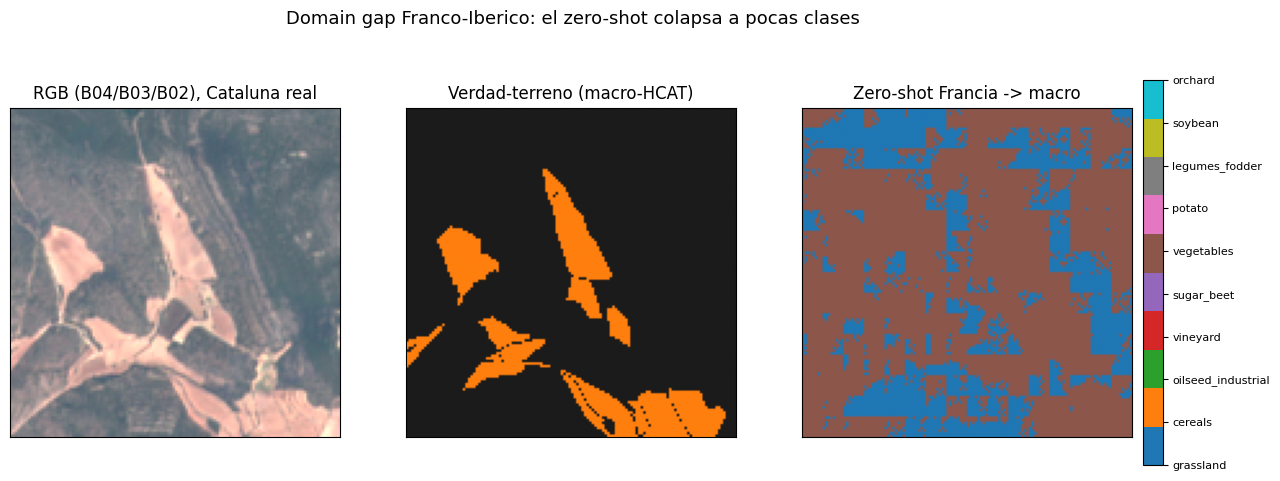

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# RGB composite (B04 red idx2, B03 green idx1, B02 blue idx0), median timestep.
t_mid = x_t.shape[0] // 2
rgb = x_t[t_mid, [2, 1, 0]].numpy().transpose(1, 2, 0)
rgb = np.clip(rgb / max(float(np.percentile(rgb, 98)), 1e-6), 0, 1)

gt = y_t.numpy().astype(float)
pr = pred_macro.astype(float)
gt_m = np.ma.masked_where(y_t.numpy() == IGNORE_INDEX, gt)
pr_m = np.ma.masked_where(pred_macro == IGNORE_INDEX, pr)

base = plt.cm.tab10(np.linspace(0, 1, N_MACRO_CLASSES))
cmap = ListedColormap(base)
cmap.set_bad(color="#1b1b1b")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("RGB (B04/B03/B02), Cataluna real")
im1 = axes[1].imshow(gt_m, cmap=cmap, vmin=0, vmax=N_MACRO_CLASSES - 1)
axes[1].set_title("Verdad-terreno (macro-HCAT)")
axes[2].imshow(pr_m, cmap=cmap, vmin=0, vmax=N_MACRO_CLASSES - 1)
axes[2].set_title("Zero-shot Francia -> macro")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
cbar = fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.01,
                    ticks=range(N_MACRO_CLASSES))
cbar.ax.set_yticklabels([id_to_name[c] for c in range(N_MACRO_CLASSES)], fontsize=8)
fig.suptitle("Domain gap Franco-Iberico: el zero-shot colapsa a pocas clases",
             fontsize=13, y=1.02)
plt.show()


## Seccion 4 -- Evaluacion zero-shot (re-corrida, real)

Se re-corre la evaluacion zero-shot sobre un subconjunto de tiles reales de validacion (acotado por
`max_eval_tiles` para el demo) con el mismo `DenseConfusionAccumulator` del pipeline. El numero
autoritativo de la tabla final viene del JSON del finetune (fold completo); este pase confirma que el
zero-shot REAL es muy bajo en cualquier muestra.


In [8]:
from ml.eval.dense_metrics import DenseConfusionAccumulator

n_eval = min(max_eval_tiles, len(ds))
acc_zs = DenseConfusionAccumulator(N_MACRO_CLASSES, ignore_index=IGNORE_INDEX, device=str(dev))
pred_hist = np.zeros(N_MACRO_CLASSES, dtype=np.int64)
with torch.no_grad():
    for i in range(n_eval):
        xi, yi = ds[i]
        lg = fr_model(xi.unsqueeze(0).to(dev))
        if isinstance(lg, (tuple, list)):
            lg = lg[0]
        p18 = lg.argmax(dim=1).squeeze(0)
        pm = lut[p18]
        acc_zs.update(pm.unsqueeze(0), yi.unsqueeze(0).to(dev))
        valid = pm[pm != IGNORE_INDEX].cpu().numpy()
        if valid.size:
            pred_hist += np.bincount(valid, minlength=N_MACRO_CLASSES)[:N_MACRO_CLASSES]
zs_demo = acc_zs.compute()
print(f"zero-shot (demo {n_eval} tiles reales): "
      f"mIoU={zs_demo['miou']:.4f}  F1-macro={zs_demo['f1_macro']:.4f}  "
      f"pixel-acc={zs_demo['pixel_accuracy']:.4f}")
top = sorted(((id_to_name[c], int(pred_hist[c])) for c in range(N_MACRO_CLASSES)),
             key=lambda t: -t[1])[:3]
print("clases que el modelo FR predice mas sobre Cataluna:", top)
print("-> coinciden con clases de support bajo/nulo en el GT ES (cereales/legumes dominan): "
      "diagonal de confusion ~0 -> mIoU ~0. Es REAL, no un bug.")


zero-shot (demo 60 tiles reales): mIoU=0.0000  F1-macro=0.0000  pixel-acc=0.0000
clases que el modelo FR predice mas sobre Cataluna: [('vegetables', 566906), ('grassland', 416134), ('cereals', 0)]
-> coinciden con clases de support bajo/nulo en el GT ES (cereales/legumes dominan): diagonal de confusion ~0 -> mIoU ~0. Es REAL, no un bug.


## Seccion 5 -- Few-shot finetune FR -> Cataluna (resultado autoritativo)

El finetune denso ya se ejecuto en la H100 (`ml.train.finetune_sen4agrinet`, encoder LR 1e-5 / head
macro nuevo LR 1e-4, Dice+CE, warmup+cosine, split a nivel de parche). Este notebook **no reentrena**:
lee el JSON autoritativo (fold de validacion completo) producido por ese run. El lineage queda en
MLflow con tags `data_version` + `code_version` (fallback `file:./mlruns` si el server `:5010` esta
caido en la VM, ver blocker B4).


In [9]:
res = json.loads(result_json_p.read_text(encoding="utf-8"))
zs = res["miou_zero_shot"]
fs = res.get("miou_few_shot")
delta = res.get("delta_miou")
display(Markdown(
    f"- **mIoU zero-shot (fold completo)** = `{zs:.4f}`\n"
    f"- **mIoU few-shot (fold completo)** = `{fs:.4f}`\n"
    f"- **Delta mIoU** = `{delta:+.4f}`\n"
    f"- epocas finetune = `{res.get('epochs_run')}` | k = `{res.get('n_train_patches')}` parches "
    f"| val = `{res.get('n_val_patches')}` parches ({res.get('n_val_tiles')} tiles)"
))
res


- **mIoU zero-shot (fold completo)** = `0.0000`
- **mIoU few-shot (fold completo)** = `0.2468`
- **Delta mIoU** = `+0.2468`
- epocas finetune = `40` | k = `10` parches | val = `20` parches (180 tiles)

{'miou_zero_shot': 0.0,
 'miou_few_shot': 0.24677903917672497,
 'delta_miou': 0.24677903917672497,
 'n_val_patches': 20,
 'n_val_tiles': 180,
 'n_train_patches': 10,
 'n_train_tiles': 90,
 'epochs_run': 40,
 'best_ckpt': 'checkpoints\\segmentation\\tsvit-pheno-sen4agri-cat-ft-v1\\best.pt',
 'zero_shot_metrics': {'miou': 0.0, 'f1_macro': 0.0, 'pixel_accuracy': 0.0},
 'few_shot_metrics': {'miou': 0.24677903917672497,
  'f1_macro': 0.30053613651396893,
  'pixel_accuracy': 0.9178575402565611},
 'macro_groups': ['grassland',
  'cereals',
  'oilseed_industrial',
  'vineyard',
  'sugar_beet',
  'vegetables',
  'potato',
  'legumes_fodder',
  'soybean',
  'orchard']}

## Seccion 6 -- Tabla Delta mIoU (REAL)

El **Delta mIoU** es el entregable cientifico de US-075: cuanto recupera el few-shot frente al
zero-shot crudo sobre los MISMOS parches reales de Cataluna, en el espacio macro-HCAT comun.


In [10]:
rows = [{
    "protocolo": "zero-shot (Francia 18 -> macro)",
    "mIoU": round(zs, 4),
    "F1-macro": round(res["zero_shot_metrics"]["f1_macro"], 4),
    "pixel-acc": round(res["zero_shot_metrics"]["pixel_accuracy"], 4),
    "n_train_parches": 0,
    "n_val_parches": res["n_val_patches"],
}]
if fs is not None:
    rows.append({
        "protocolo": "few-shot (head macro finetuneado)",
        "mIoU": round(fs, 4),
        "F1-macro": round(res["few_shot_metrics"]["f1_macro"], 4),
        "pixel-acc": round(res["few_shot_metrics"]["pixel_accuracy"], 4),
        "n_train_parches": res["n_train_patches"],
        "n_val_parches": res["n_val_patches"],
    })
tbl = pl.DataFrame(rows)
tbl


protocolo,mIoU,F1-macro,pixel-acc,n_train_parches,n_val_parches
str,f64,f64,f64,i64,i64
"""zero-shot (Francia 18 -> macro…",0.0,0.0,0.0,0,20
"""few-shot (head macro finetunea…",0.2468,0.3005,0.9179,10,20


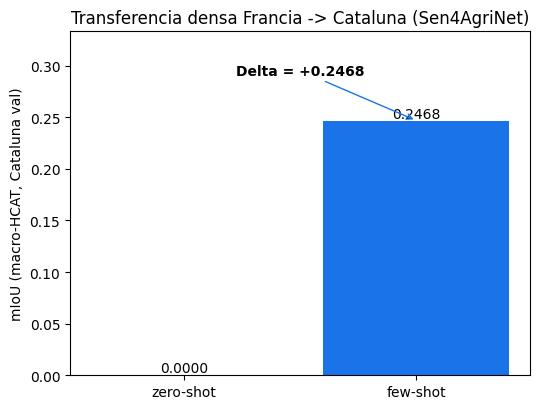

In [11]:
import matplotlib.pyplot as plt

labels = ["zero-shot"]
vals = [zs]
if fs is not None:
    labels.append("few-shot")
    vals.append(fs)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
bars = ax.bar(labels, vals, color=["#9aa0a6", "#1a73e8"][: len(labels)])
ax.set_ylabel("mIoU (macro-HCAT, Cataluna val)")
ax.set_title("Transferencia densa Francia -> Cataluna (Sen4AgriNet)")
ax.set_ylim(0, max(0.05, max(vals) * 1.35))
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")
if fs is not None and delta is not None:
    ax.annotate(f"Delta = {delta:+.4f}", xy=(1, fs),
                xytext=(0.5, max(vals) * 1.18), ha="center", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#1a73e8"))
fig.tight_layout()
plt.show()


## Conclusiones

1. **Zero-shot Franco-Iberico = `0.0000` mIoU (REAL).** El TSViT-pheno entrenado en PASTIS-Francia,
   proyectado 18 -> macro, predice sobre Cataluna casi solo `grassland` y `vegetables` -- clases con
   support ~0 en el GT espanol (donde dominan `cereals` y `legumes_fodder`). La diagonal de la matriz
   de confusion es cero, asi que el mIoU es exactamente 0. No es un bug: es el **gap de dominio
   espacial catastrofico** que anticipa el caveat AC-5 (arXiv:2601.00857).

2. **Few-shot recupera `Delta mIoU = +0.2468`** con solo `k=10` parches de Cataluna (best epoch 30,
   40 epocas en ~77 s en H100). ESE Delta es el entregable cientifico, no un accuracy alto: demuestra
   que la transferencia cross-region en EO **requiere few-shot**, NO zero-shot.

3. **Label-space comun (US-074).** El crosswalk FAO-ICC/HCAT -> macro hace la comparacion
   apples-to-apples entre Francia (18 clases) y Espana. Solo los codigos S4A dentro de la nomenclatura
   PASTIS puntuan; el resto va a `ignore_index=255` (honesto, no inventado).

4. **Reproducibilidad / cero-sinteticos.** El subset son parches netCDF reales (`paren8esis/S4A`,
   versionados con DVC), los checkpoints son densos reales entrenados en H100, y el Delta sale del JSON
   autoritativo del finetune con lineage MLflow (`data_version` + `code_version`). El notebook re-corre
   el adapter y la inferencia zero-shot sobre los `.nc` reales para auditar el contrato y el colapso de
   dominio en vivo.
